In [10]:
from utils.data_loader import load_breast_cancer_data, load_folktables_income_data, load_loan_prediction, \
    load_gbs_gesis, load_gbs_allensbach, load_folktables_employment_data
from utils.metrics import train_feature_weighted_random_forest
import seaborn as sns
import numpy as np
np.random.seed(5)
from utils.sampling import  sample_with_test_set
from sklearn.preprocessing import StandardScaler
from weighting_methods.feature_weighted_maximum_representative_subsampling import  mrs
from weighting_methods.maximum_representative_subsampling import mrs_step
from utils.metrics import compute_classification_metrics_random_forest, \
    compute_classification_metrics_tree, compute_classification_metrics_feature_weight, compute_feature_weight_with_temperature
from utils.metrics import compute_test_metrics_fw_mrs, train_random_forest_classifier_mrs, compute_test_metrics_mrs


In [11]:
df, columns, target = load_folktables_income_data()
df[columns] = StandardScaler().fit_transform(df[columns])
# N = df[df["label"] == 1]
# R = df[df["label"] == 0]
N, R, T = sample_with_test_set(
           "less_positive_class",
           df,
           target,
           train_fraction=0.5,
           bias_fraction=0.1,
           test_fraction=0.1,
           columns=columns,
       )

In [12]:
# _, feature_importance = mrs_without_cv(dropped_N, R, columns, class_weights="balanced", random_state=5, drop=20)
drop_ids, feature_importance_cv, shap_values = mrs(N, R, columns, class_weights="balanced", random_state=5, drop=20)

<Axes: >

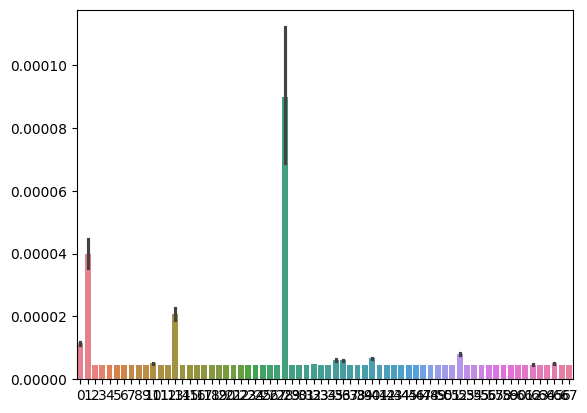

In [13]:
feature_weights = compute_feature_weight_with_temperature(0.01, shap_values)
sns.barplot(feature_weights)

In [14]:
R_feature_weights = np.array([[np.nan] * len(columns)] * len(R))
all_feature_weights = np.concatenate([shap_values, R_feature_weights])

In [15]:
seed = 5
max_features = "sqrt"
sample_weights = np.ones(len(N)) / len(N)

feature_weights_list = []
# budgets = [None, 0.1, 0.01, 0.005, 0.001]
budgets = [None, 0.1, 0.05, 0.01, 0.005]
# for budget in budgets:
#     feature_weights = compute_feature_weight_with_temperature(budget, feature_importance_cv)
#     feature_weights_list.append(feature_weights)

In [16]:
for i, budget in enumerate(budgets):
    auroc = compute_test_metrics_fw_mrs(
       N,
       R,
       columns,
       random_state=seed,
       feature_weight=all_feature_weights,
       method=train_feature_weighted_random_forest,
       class_weight="balanced",
       max_features="sqrt",
       splitter="feature_weighted_best",
       n_splits_test=10,
       n_estimators=200,
       draw_with_feature_weight=True,
       budget=budget,
       )
    print(f"{budget}: {auroc}")

None: 0.6178848725091812
0.1: 0.6225362218917422
0.05: 0.6199792780873119
0.01: 0.6170159020243065
0.005: 0.6080372453325514


None: 0.6195240704345581
0.1: 0.6181144636015325\
0.05: 0.617988343209656\
0.01: 0.6095037358803328\
0.005: 0.5953715234351736\
0.001: 0.5382615351974273\

In [17]:
for i,budget in enumerate(budgets):
    auroc, auprc, _, _, _, _ = compute_classification_metrics_random_forest(
            N,
            R,
            R,
            columns,
            sample_weights,
            all_feature_weights,
            target,
            random_state=seed,
            n_splits=10,
            splitter="feature_weighted_best",
            n_estimators=200,
            draw_with_feature_weight=True,
            compute_feature_importance=False,
            budget=budget
    )
    print(f"{budget} Auroc: {auroc}")
    print(f"{budget} AUPRC: {auprc}\n")

None Auroc: 0.8497314454656177
None AUPRC: 0.8036112850081967

0.1 Auroc: 0.8494479642663167
0.1 AUPRC: 0.8065822594283442

0.05 Auroc: 0.8491878451791262
0.05 AUPRC: 0.8073662713302339

0.01 Auroc: 0.8268812615164236
0.01 AUPRC: 0.7829596559312635

0.005 Auroc: 0.7856421162749568
0.005 AUPRC: 0.7349098083868644



None Auroc: 0.9897685185185185\
None AUPRC: 0.9952434438490332

0.05 Auroc: 0.9884722222222222\
0.05 AUPRC: 0.9948154401835849

0.01 Auroc: 0.987962962962963\
0.01 AUPRC: 0.9943947194109652

0.005 Auroc: 0.9855324074074073\
0.005 AUPRC: 0.9933045518147399